# Análisis de Datos de Viviendas con K-means

En este notebook realizamos un análisis exploratorio de un conjunto de datos sobre viviendas, incluyendo visualizaciones y estadísticas descriptivas por grupos.

In [1]:
import pandas as pd
datos = pd.read_csv("housing.csv")

Mostramos las primeras filas del DataFrame para observar la estructura y las variables que contiene el conjunto de datos.

In [2]:
datos.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


Creamos un gráfico de dispersión que muestra la ubicación geográfica de las viviendas según latitud y longitud, diferenciando los puntos por segmento económico.

<Axes: xlabel='latitude', ylabel='longitude'>

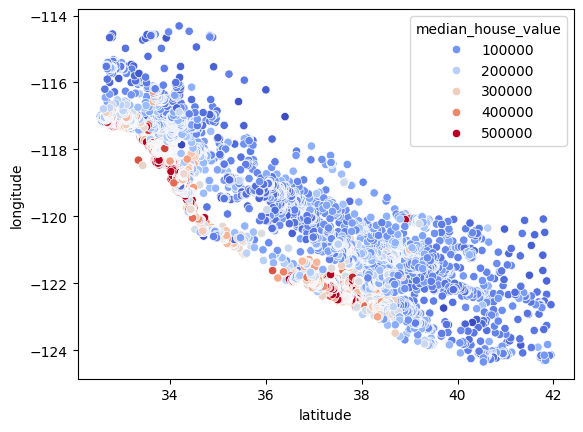

In [4]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value",
               palette="coolwarm")

In [12]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="segmento_economico", palette="bright")

ValueError: Could not interpret value `latitude` for `x`. An entry with this name does not appear in `data`.

Esta celda selecciona las columnas de latitud, longitud e ingreso mediano para usarlas en el análisis de clustering.

In [6]:
datos.loc[:, ["latitude", "longitude", "median_income"]]

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


Aquí se utiliza el algoritmo K-Means para agrupar las viviendas en 6 segmentos basándose en su latitud, longitud e ingreso mediano.

In [7]:
from sklearn.cluster import KMeans
x = datos.loc[:, ["latitude", "longitude", "median_income"]]
modelo = KMeans(n_clusters=6)
predicciones = modelo.fit_predict(x)

Esta celda muestra el tamaño de las `predicciones`, que es el número de asignaciones de cluster realizadas.

In [8]:
predicciones.shape

(20640,)

Se añade la columna `segmento_economico` al DataFrame `x`, que contiene el cluster asignado a cada vivienda.

In [9]:
x["segmento_economico"] = predicciones

Esta celda muestra el DataFrame x con la nueva columna

In [10]:
x

,latitude,longitude,median_income,segmento_economico
0,37.88,-122.23,8.3252,4
1,37.86,-122.22,8.3014,4
2,37.85,-122.24,7.2574,4
3,37.85,-122.25,5.6431,1
4,37.85,-122.25,3.8462,1
...,...,...,...,...
20635,39.48,-121.09,1.5603,5
20636,39.49,-121.21,2.5568,5
20637,39.43,-121.22,1.7000,5
20638,39.43,-121.32,1.8672,5


Aquí se cuenta cuántas viviendas hay en cada segmento económico.

In [11]:
x["segmento_economico"].value_counts()

,count
segmento_economico,
0,6584
3,4625
5,4521
1,3479
2,760
4,671


En esta actividad gráfico  muestra las viviendas, coloreadas según el segmento económico al que pertenecen, para visualizar la distribución de clusters.

<Axes: xlabel='latitude', ylabel='longitude'>

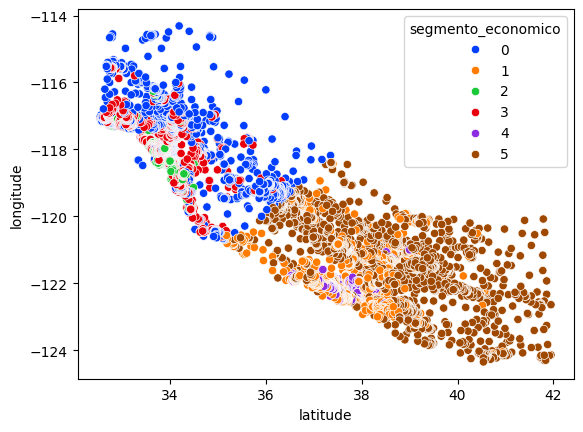

In [13]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=x, hue="segmento_economico",
               palette="bright")

En esta actividad gráfico de barras muestra la cantidad de viviendas en cada segmento económico.

<Axes: xlabel='segmento_economico', ylabel='count'>

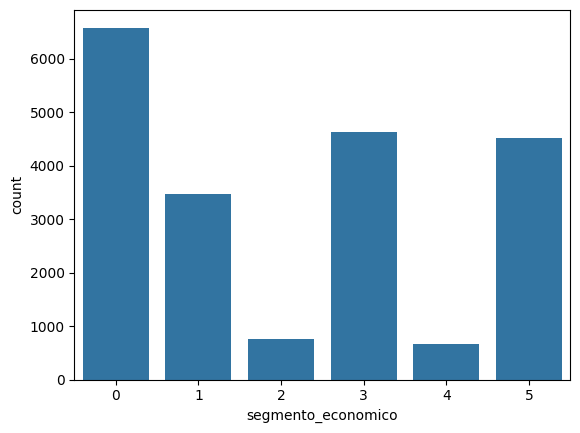

In [14]:
sb.countplot(x="segmento_economico", data=x)

Esta celda calcula el ingreso mediano promedio para cada segmento económico.

In [15]:
x.groupby(["segmento_economico"])["median_income"].mean()

,median_income
segmento_economico,
0,2.633187
1,4.629799
2,8.941455
3,4.921029
4,8.265194
5,2.509503
